# app

OpenCV Feature Analysis

Анализ признаков, извлечённых из ROI зоны пайки.

Цели ноутбука:

1. Загрузить OpenCV-признаки из `frame_features_roi.csv`.
2. Проверить распределение признаков по стадиям.
3. Сравнить признаки между классами.
4. Использовать video-level split: train / val / test.
5. Обучить простой baseline-классификатор на OpenCV-признаках.
6. Получить confusion matrix и classification report.
7. Сделать предварительные выводы о применимости морфологического подхода.

## bootstrap

In [4]:
import os
from pathlib import Path

def is_colab() -> bool:
    try:
        import google.colab  # type: ignore
        return True
    except ImportError:
        return False
    

IN_COLAB = is_colab()

if IN_COLAB:
    REPO_ROOT = Path("/content") / "BrazingSense"
else:
    REPO_ROOT = Path.cwd().resolve()

if not (REPO_ROOT / ".git").exists():
    raise RuntimeError(f"REPO_ROOT не похож на корень репозитория: {REPO_ROOT}")

os.chdir(REPO_ROOT)

## packages

In [5]:
from pathlib import Path
import json
import warnings
from collections import Counter

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [7]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    accuracy_score,
    f1_score,
)
from sklearn.inspection import permutation_importance

## env

In [8]:
warnings.filterwarnings("ignore")

In [9]:
FPS = 3
ROOT = Path()
DRIVE_FOLDER = Path('/content/drive/MyDrive/Colab Notebooks/Diploma')

In [10]:
DATA = ROOT / "data" 

DATA_ANNOTATIONS = DATA / "annotations" 
STAGE_INTERVALS_PATH = DATA_ANNOTATIONS / "stage_intervals.csv"
FRAME_LABELS_PATH = DATA_ANNOTATIONS / f"frame_labels_{FPS}.csv"
FRAME_STATS_PATH = DATA_ANNOTATIONS / f"frame_dataset_stats_{FPS}.json"

DATA_SPLITS = DATA_ANNOTATIONS / f"splits_{FPS}"
TRAIN_PATH = DATA_SPLITS / "train.csv"
VAL_PATH = DATA_SPLITS / "val.csv"
TEST_PATH = DATA_SPLITS / "test.csv"

DATA_PROCESSED = DATA / 'processed'
DATA_PROCESSED_FRAMES = DATA_PROCESSED / f'frames_{FPS}'

In [11]:
DRIVE_PROCESSED_FRAMES_FOLDER = DRIVE_FOLDER / DATA_PROCESSED_FRAMES

In [12]:
REPORTS = ROOT / "reports" 

REPORTS_CV_FEATURES = REPORTS / f"cv_features_{FPS}"
ROI_FEATURES_PATH = REPORTS_CV_FEATURES / "frame_features_roi.csv"
ROI_SUMMARY_PATH = REPORTS_CV_FEATURES / "summary_by_stage_roi.csv"
FULL_FEATURES_PATH = REPORTS_CV_FEATURES / "frame_features.csv"
FULL_SUMMARY_PATH = REPORTS_CV_FEATURES / "summary_by_stage.csv"

REPORTS_DIR = REPORTS / f"cv_feature_analysis_{FPS}"
FIGURES_DIR = REPORTS / "figures" / f"cv_feature_analysis_{FPS}"

In [13]:
REPORTS_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

assert ROI_FEATURES_PATH.exists(), ROI_FEATURES_PATH
assert FULL_FEATURES_PATH.exists(), FULL_FEATURES_PATH
assert TRAIN_PATH.exists(), TRAIN_PATH
assert VAL_PATH.exists(), VAL_PATH
assert TEST_PATH.exists(), TEST_PATH

# lib

# model

# runtime

In [14]:
# if IN_COLAB:
#     from google.colab import drive # type: ignore
#     drive.mount("/content/drive")
#     !cp -r -v "$DRIVE_PROCESSED_FRAMES_FOLDER"/. "$DATA_PROCESSED_FRAMES"/

In [15]:
STAGE_ORDER = [
    "inactive_preparation",
    "flux_activation",
    "active_brazing",
    "stabilization",
]

STAGE_TO_ID = {
    "inactive_preparation": 0,
    "flux_activation": 1,
    "active_brazing": 2,
    "stabilization": 3,
}

ID_TO_STAGE = {v: k for k, v in STAGE_TO_ID.items()}

META_COLUMNS = {
    "video_id",
    "frame_path",
    "timestamp_s",
    "stage_id",
    "stage_name",
}

## roi vs full-frame

In [16]:
full_features_df = pd.read_csv(FULL_FEATURES_PATH)
print("Full-frame features:", full_features_df.shape)
full_features_df.head()

Full-frame features: (3140, 27)


,video_id,frame_path,timestamp_s,stage_id,stage_name,brightness_mean,brightness_std,value_mean,value_std,saturation_mean,...,blue_mean,red_green_diff,red_blue_diff,white_area_ratio,specular_highlight_ratio,dark_area_ratio,warm_area_ratio,edge_density,laplacian_var,frame_diff_score
0,MVI_6265,data/processed/frames_3/MVI_6265/MVI_6265_0000...,0.000000,0,inactive_preparation,128.460898,47.583463,154.716689,53.487308,71.106578,...,153.841086,-20.482326,-42.218423,0.186655,0.053238,0.040309,0.002078,0.027926,34.363182,0.000000
1,MVI_6265,data/processed/frames_3/MVI_6265/MVI_6265_0000...,0.333333,0,inactive_preparation,128.459645,47.545999,154.901730,53.443930,71.517717,...,154.024537,-20.565014,-42.481491,0.186047,0.053218,0.039935,0.002500,0.026598,29.788471,5.114300
2,MVI_6265,data/processed/frames_3/MVI_6265/MVI_6265_0000...,0.666667,0,inactive_preparation,128.362755,47.286946,154.694524,53.251769,71.511494,...,153.793751,-20.639960,-42.380411,0.183875,0.051164,0.039654,0.001878,0.028691,34.524581,8.809488
3,MVI_6265,data/processed/frames_3/MVI_6265/MVI_6265_0000...,1.000000,0,inactive_preparation,128.363892,47.109884,154.883728,52.951097,71.752391,...,154.004274,-20.534812,-42.546715,0.183105,0.050878,0.038498,0.002311,0.028261,33.007998,5.193733
4,MVI_6265,data/processed/frames_3/MVI_6265/MVI_6265_0000...,1.333333,0,inactive_preparation,128.283749,47.164114,154.909987,53.012578,72.026012,...,154.034476,-20.609627,-42.721609,0.182549,0.051340,0.038198,0.002055,0.028275,34.129252,1.731335


In [17]:
roi_features_df = pd.read_csv(ROI_FEATURES_PATH)
print("ROI features:", roi_features_df.shape)
roi_features_df.head()

ROI features: (3140, 27)


,video_id,frame_path,timestamp_s,stage_id,stage_name,brightness_mean,brightness_std,value_mean,value_std,saturation_mean,...,blue_mean,red_green_diff,red_blue_diff,white_area_ratio,specular_highlight_ratio,dark_area_ratio,warm_area_ratio,edge_density,laplacian_var,frame_diff_score
0,MVI_6265,data/processed/frames_3/MVI_6265/MVI_6265_0000...,0.000000,0,inactive_preparation,145.025702,56.764680,179.579174,59.605029,81.634146,...,178.895822,-24.509840,-54.469326,0.186183,0.295285,0.001684,0.000513,0.047298,63.083993,0.000000
1,MVI_6265,data/processed/frames_3/MVI_6265/MVI_6265_0000...,0.333333,0,inactive_preparation,144.239944,56.803818,178.913737,60.100888,82.045766,...,178.180826,-24.558260,-54.586151,0.180345,0.293689,0.002943,0.000601,0.044996,52.564422,9.295525
2,MVI_6265,data/processed/frames_3/MVI_6265/MVI_6265_0000...,0.666667,0,inactive_preparation,142.540722,56.373133,177.178613,60.250726,82.260545,...,176.394787,-24.274034,-54.300898,0.169551,0.277763,0.004956,0.000449,0.047233,64.375782,18.387129
3,MVI_6265,data/processed/frames_3/MVI_6265/MVI_6265_0000...,1.000000,0,inactive_preparation,142.187306,56.462278,176.990377,60.168118,82.545638,...,176.208693,-24.095686,-54.363881,0.168003,0.275397,0.005076,0.000481,0.048404,61.407665,7.876993
4,MVI_6265,data/processed/frames_3/MVI_6265/MVI_6265_0000...,1.333333,0,inactive_preparation,142.097017,56.628473,177.135381,60.244167,82.938773,...,176.348669,-24.114106,-54.641788,0.169687,0.278123,0.004675,0.000609,0.047193,62.888918,2.078292


In [18]:
comparison_features = [
    "brightness_mean",
    "value_mean",
    "saturation_mean",
    "white_area_ratio",
    "specular_highlight_ratio",
    "edge_density",
    "laplacian_var",
    "frame_diff_score",
]

comparison_features = [
    f for f in comparison_features
    if f in full_features_df.columns and f in roi_features_df.columns
]

comparison_features

['brightness_mean',
 'value_mean',
 'saturation_mean',
 'white_area_ratio',
 'specular_highlight_ratio',
 'edge_density',
 'laplacian_var',
 'frame_diff_score']

### stage separation 

In [19]:
def compute_stage_separation(df, feature_columns, stage_order):
    rows = []

    for feature in feature_columns:
        stage_means = df.groupby("stage_name")[feature].mean().reindex(stage_order)
        global_std = df[feature].std()

        raw_range = stage_means.max() - stage_means.min()

        if global_std > 0:
            normalized_range = raw_range / global_std
        else:
            normalized_range = 0.0

        rows.append({
            "feature": feature,
            "stage_mean_min": stage_means.min(),
            "stage_mean_max": stage_means.max(),
            "stage_mean_range": raw_range,
            "global_std": global_std,
            "normalized_stage_separation": normalized_range,
        })

    return pd.DataFrame(rows).sort_values(
        "normalized_stage_separation",
        ascending=False,
    )

### versus

In [20]:
full_sep = compute_stage_separation(
    full_features_df,
    comparison_features,
    STAGE_ORDER,
)

roi_sep = compute_stage_separation(
    roi_features_df,
    comparison_features,
    STAGE_ORDER,
)

comparison_df = full_sep[[
    "feature",
    "normalized_stage_separation",
    "stage_mean_range",
]].rename(columns={
    "normalized_stage_separation": "full_normalized_separation",
    "stage_mean_range": "full_stage_mean_range",
}).merge(
    roi_sep[[
        "feature",
        "normalized_stage_separation",
        "stage_mean_range",
    ]].rename(columns={
        "normalized_stage_separation": "roi_normalized_separation",
        "stage_mean_range": "roi_stage_mean_range",
    }),
    on="feature",
)

comparison_df["roi_gain"] = (
    comparison_df["roi_normalized_separation"]
    / comparison_df["full_normalized_separation"].replace(0, np.nan)
)

comparison_df = comparison_df.sort_values(
    "roi_normalized_separation",
    ascending=False,
)

comparison_df

,feature,full_normalized_separation,full_stage_mean_range,roi_normalized_separation,roi_stage_mean_range,roi_gain
2,brightness_mean,0.865615,3.563231,1.714273,15.165470,1.980409
1,value_mean,0.898089,3.951101,1.700564,16.988161,1.893537
5,edge_density,0.533245,0.000928,1.372221,0.008193,2.573343
3,specular_highlight_ratio,0.741419,0.015808,1.341692,0.093591,1.809628
6,laplacian_var,0.445793,0.960883,1.308246,8.311203,2.934651
4,white_area_ratio,0.577383,0.022599,1.266289,0.091397,2.193152
0,frame_diff_score,1.277590,1.127263,0.975089,3.250816,0.763225
7,saturation_mean,0.169185,1.344672,0.263415,2.051563,1.556964


In [21]:
comparison_output_path = REPORTS / f"full_frame_vs_roi_feature_separation_{FPS}.csv"
comparison_df.to_csv(comparison_output_path, index=False)

comparison_output_path

PosixPath('reports/full_frame_vs_roi_feature_separation_3.csv')

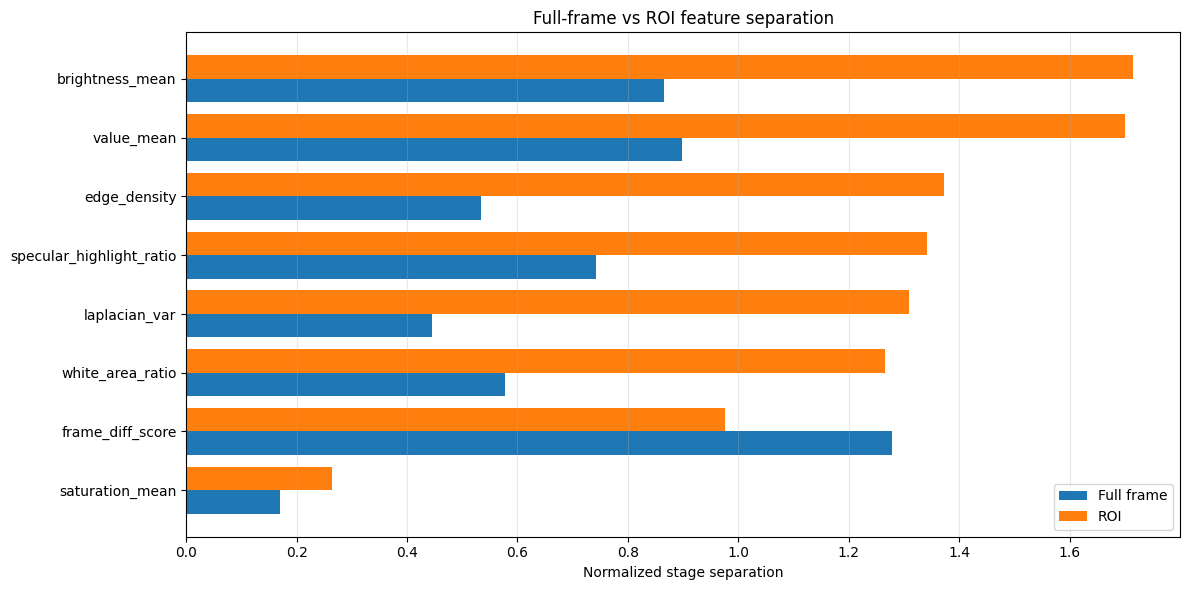

In [22]:
plot_df = comparison_df.sort_values("roi_normalized_separation", ascending=True)

x = np.arange(len(plot_df))
bar_width = 0.4

plt.figure(figsize=(12, 6))

plt.barh(
    x - bar_width / 2,
    plot_df["full_normalized_separation"],
    height=bar_width,
    label="Full frame",
)

plt.barh(
    x + bar_width / 2,
    plot_df["roi_normalized_separation"],
    height=bar_width,
    label="ROI",
)

plt.yticks(x, plot_df["feature"])
plt.xlabel("Normalized stage separation")
plt.title("Full-frame vs ROI feature separation")
plt.grid(axis="x", alpha=0.3)
plt.legend()
plt.tight_layout()

output_path = FIGURES_DIR / f"full_frame_vs_roi_feature_separation_{FPS}.png"
plt.savefig(output_path, dpi=160)
plt.show()

In [23]:
better_roi_count = (comparison_df["roi_normalized_separation"] > comparison_df["full_normalized_separation"]).sum()
total_count = len(comparison_df)

print(f"ROI лучше full-frame по {better_roi_count} из {total_count} ключевых признаков.")

display(
    comparison_df[[
        "feature",
        "full_normalized_separation",
        "roi_normalized_separation",
        "roi_gain",
    ]]
)

ROI лучше full-frame по 7 из 8 ключевых признаков.


,feature,full_normalized_separation,roi_normalized_separation,roi_gain
2,brightness_mean,0.865615,1.714273,1.980409
1,value_mean,0.898089,1.700564,1.893537
5,edge_density,0.533245,1.372221,2.573343
3,specular_highlight_ratio,0.741419,1.341692,1.809628
6,laplacian_var,0.445793,1.308246,2.934651
4,white_area_ratio,0.577383,1.266289,2.193152
0,frame_diff_score,1.277590,0.975089,0.763225
7,saturation_mean,0.169185,0.263415,1.556964


### Result

Сравнение признаков, рассчитанных по полному кадру и по выбранной области интереса, необходимо для обоснования перехода к ROI. Визуально значимые изменения процесса пайки локализованы в зоне соединения: меняется состояние флюса, появляются испарения, происходит плавление и протекание припоя. Поэтому признаки, рассчитанные по всему изображению, частично размываются фоном, оснасткой и областями, не связанными с процессом пайки.

Если нормированная разделимость признаков для ROI выше, чем для полного кадра, это подтверждает, что дальнейший морфологический анализ следует выполнять по области интереса.

## features_df

In [24]:
features_df = pd.read_csv(ROI_FEATURES_PATH)

print(features_df.shape)
features_df.head()

(3140, 27)


,video_id,frame_path,timestamp_s,stage_id,stage_name,brightness_mean,brightness_std,value_mean,value_std,saturation_mean,...,blue_mean,red_green_diff,red_blue_diff,white_area_ratio,specular_highlight_ratio,dark_area_ratio,warm_area_ratio,edge_density,laplacian_var,frame_diff_score
0,MVI_6265,data/processed/frames_3/MVI_6265/MVI_6265_0000...,0.000000,0,inactive_preparation,145.025702,56.764680,179.579174,59.605029,81.634146,...,178.895822,-24.509840,-54.469326,0.186183,0.295285,0.001684,0.000513,0.047298,63.083993,0.000000
1,MVI_6265,data/processed/frames_3/MVI_6265/MVI_6265_0000...,0.333333,0,inactive_preparation,144.239944,56.803818,178.913737,60.100888,82.045766,...,178.180826,-24.558260,-54.586151,0.180345,0.293689,0.002943,0.000601,0.044996,52.564422,9.295525
2,MVI_6265,data/processed/frames_3/MVI_6265/MVI_6265_0000...,0.666667,0,inactive_preparation,142.540722,56.373133,177.178613,60.250726,82.260545,...,176.394787,-24.274034,-54.300898,0.169551,0.277763,0.004956,0.000449,0.047233,64.375782,18.387129
3,MVI_6265,data/processed/frames_3/MVI_6265/MVI_6265_0000...,1.000000,0,inactive_preparation,142.187306,56.462278,176.990377,60.168118,82.545638,...,176.208693,-24.095686,-54.363881,0.168003,0.275397,0.005076,0.000481,0.048404,61.407665,7.876993
4,MVI_6265,data/processed/frames_3/MVI_6265/MVI_6265_0000...,1.333333,0,inactive_preparation,142.097017,56.628473,177.135381,60.244167,82.938773,...,176.348669,-24.114106,-54.641788,0.169687,0.278123,0.004675,0.000609,0.047193,62.888918,2.078292


In [25]:
feature_columns = [
    col for col in features_df.columns
    if col not in META_COLUMNS
]

feature_columns

['brightness_mean',
 'brightness_std',
 'value_mean',
 'value_std',
 'saturation_mean',
 'saturation_std',
 'hue_mean',
 'lab_l_mean',
 'lab_a_mean',
 'lab_b_mean',
 'red_mean',
 'green_mean',
 'blue_mean',
 'red_green_diff',
 'red_blue_diff',
 'white_area_ratio',
 'specular_highlight_ratio',
 'dark_area_ratio',
 'warm_area_ratio',
 'edge_density',
 'laplacian_var',
 'frame_diff_score']

In [26]:
print("Total frames:", len(features_df))
print("Videos:", features_df["video_id"].nunique())

features_df[["stage_id", "stage_name"]].drop_duplicates().sort_values("stage_id")

Total frames: 3140
Videos: 18


,stage_id,stage_name
0,0,inactive_preparation
95,1,flux_activation
103,2,active_brazing
119,3,stabilization


In [27]:
features_df.groupby("stage_name").size().reindex(STAGE_ORDER)

,0
stage_name,
inactive_preparation,1872
flux_activation,239
active_brazing,497
stabilization,532


In [28]:
missing_values = features_df[feature_columns].isna().sum()
missing_values[missing_values > 0]

,0


In [29]:
summary_raw = pd.read_csv(ROI_SUMMARY_PATH, header=[0, 1])

flat_columns = []
for top, bottom in summary_raw.columns:
    if str(top).startswith("Unnamed") or top == "stage_name":
        flat_columns.append("stage_name")
    else:
        flat_columns.append(f"{top}__{bottom}")

summary_raw.columns = flat_columns
summary_df = summary_raw

display(summary_df)

,stage_name,brightness_mean__mean,brightness_mean__std,brightness_mean__min,brightness_mean__max,brightness_std__mean,brightness_std__std,brightness_std__min,brightness_std__max,value_mean__mean,...,edge_density__min,edge_density__max,laplacian_var__mean,laplacian_var__std,laplacian_var__min,laplacian_var__max,frame_diff_score__mean,frame_diff_score__std,frame_diff_score__min,frame_diff_score__max
0,active_brazing,143.756073,7.362806,124.553809,163.484884,53.344848,3.024887,47.042618,61.105644,162.458042,...,0.040425,0.064274,52.953970,4.906967,41.087878,73.216760,6.644799,3.137669,1.568516,18.685734
1,flux_activation,146.520666,7.860985,127.576271,167.411323,54.819275,2.831600,50.734649,62.471173,165.843330,...,0.040786,0.056488,50.542994,3.462325,42.949231,64.615734,6.689867,3.779956,1.533047,20.092350
2,inactive_preparation,154.984609,5.352618,135.812879,170.069326,56.254899,3.014629,49.687719,65.229648,174.564382,...,0.030080,0.055718,44.642767,4.946554,34.294004,67.684129,3.905679,2.055265,0.000000,18.387129
3,stabilization,139.819140,7.069782,121.230000,156.543200,53.468044,3.248592,44.343173,60.167955,157.576221,...,0.021844,0.065092,50.008420,7.590269,26.247796,71.374980,7.156495,4.752175,1.783601,22.855726


## analyze

In [30]:
key_features = [
    "brightness_mean",
    "value_mean",
    "saturation_mean",
    "white_area_ratio",
    "specular_highlight_ratio",
    "edge_density",
    "laplacian_var",
    "frame_diff_score",
]

available_key_features = [f for f in key_features if f in features_df.columns]
available_key_features

['brightness_mean',
 'value_mean',
 'saturation_mean',
 'white_area_ratio',
 'specular_highlight_ratio',
 'edge_density',
 'laplacian_var',
 'frame_diff_score']

### boxplot

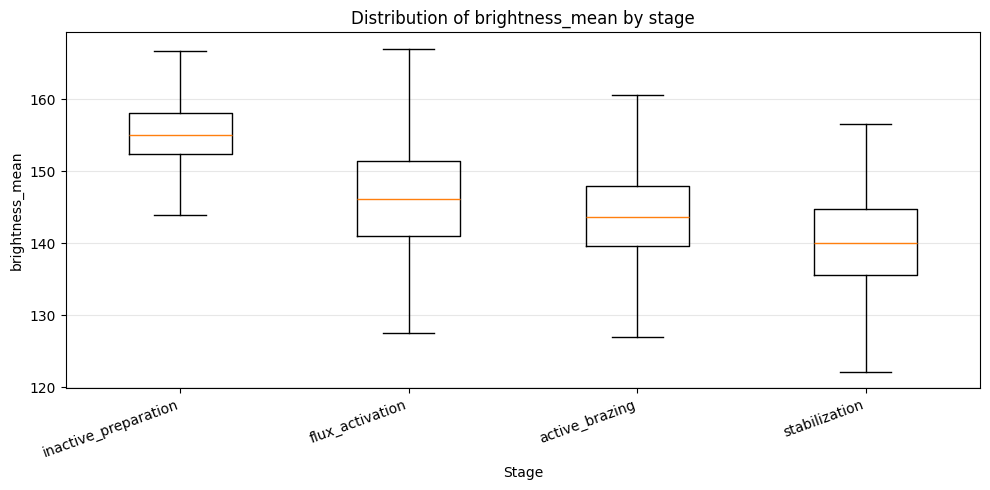

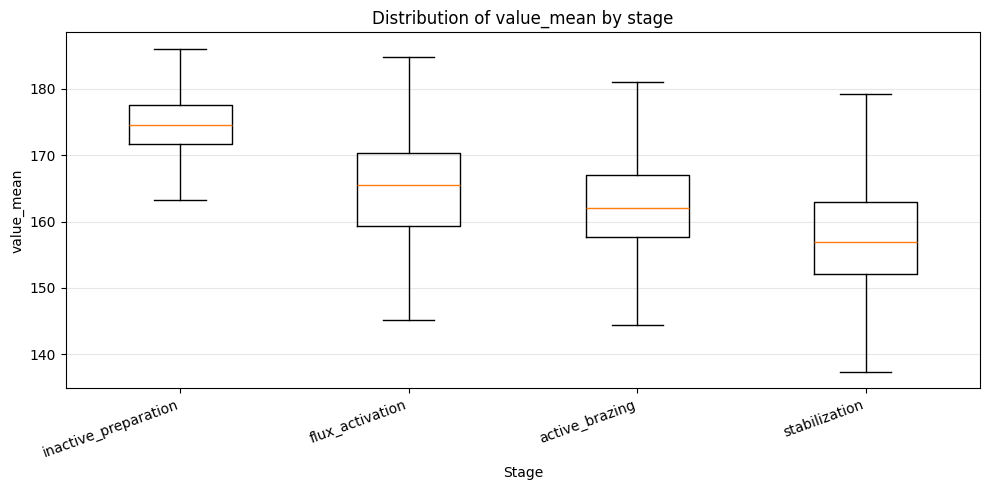

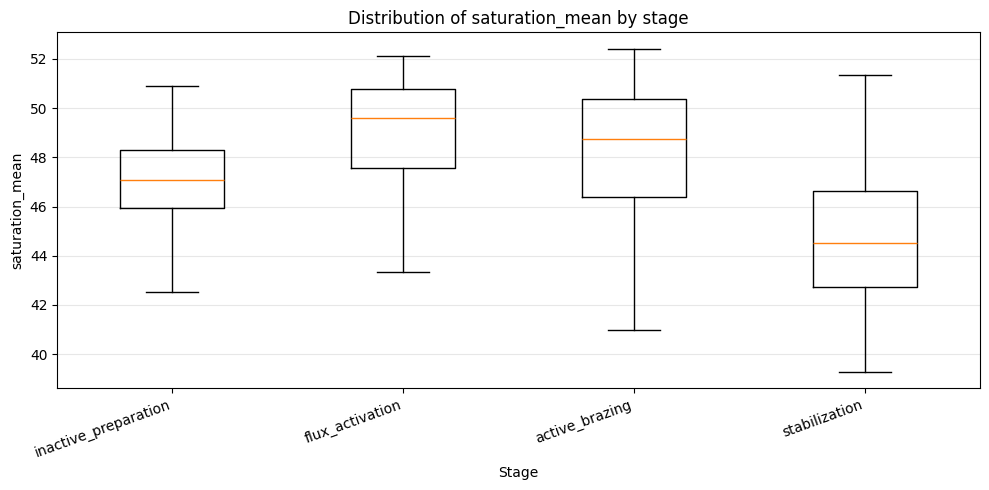

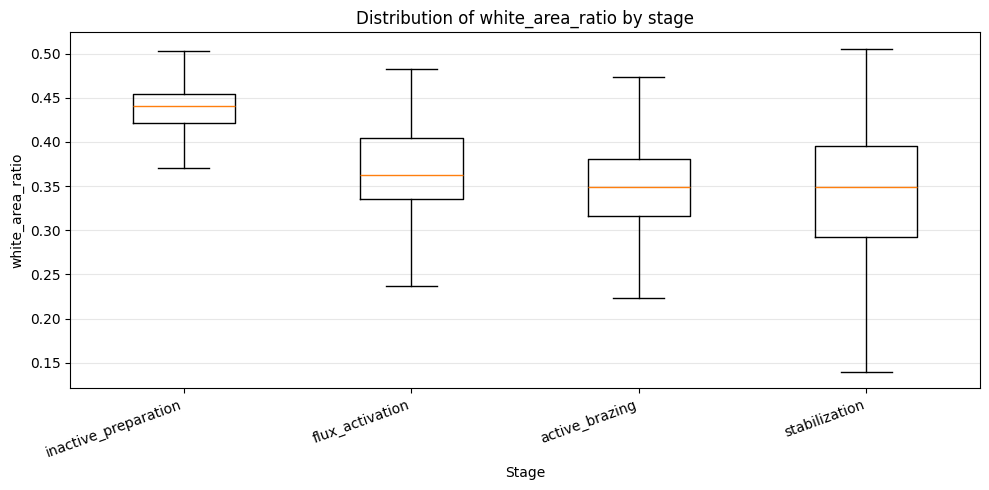

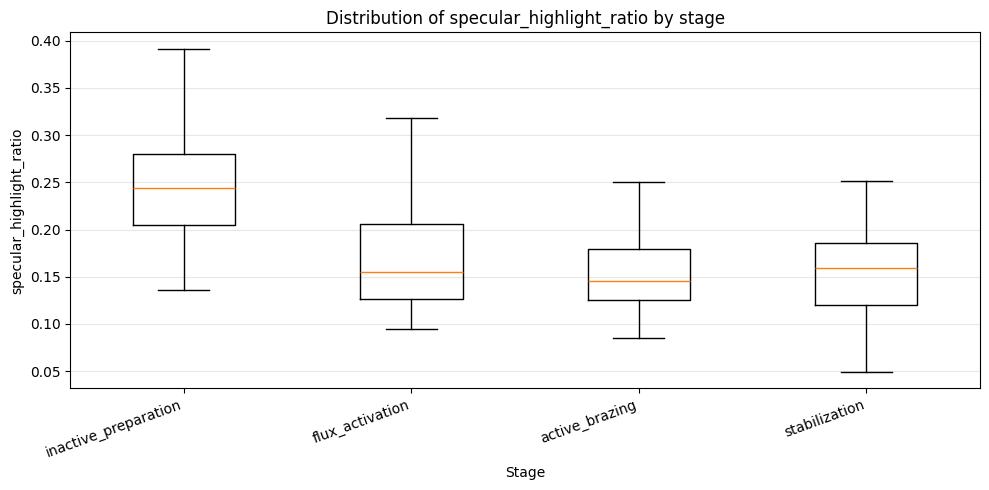

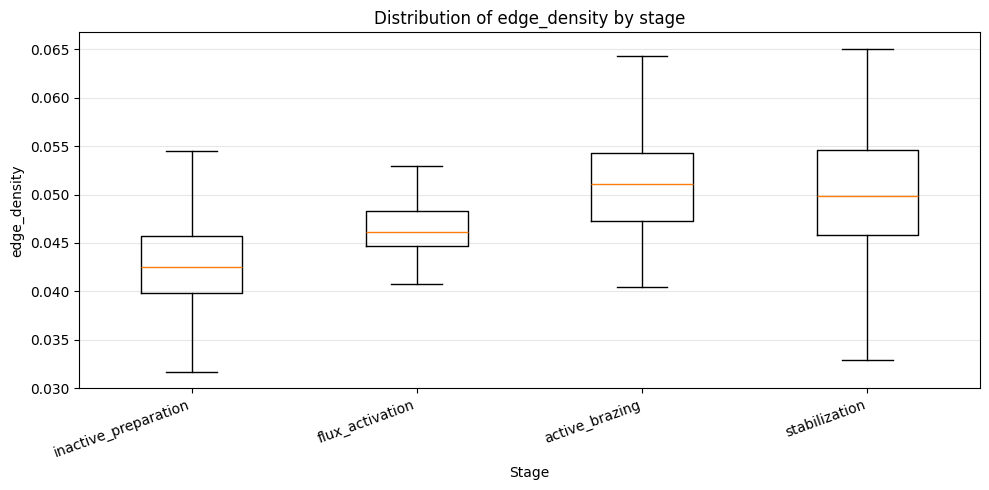

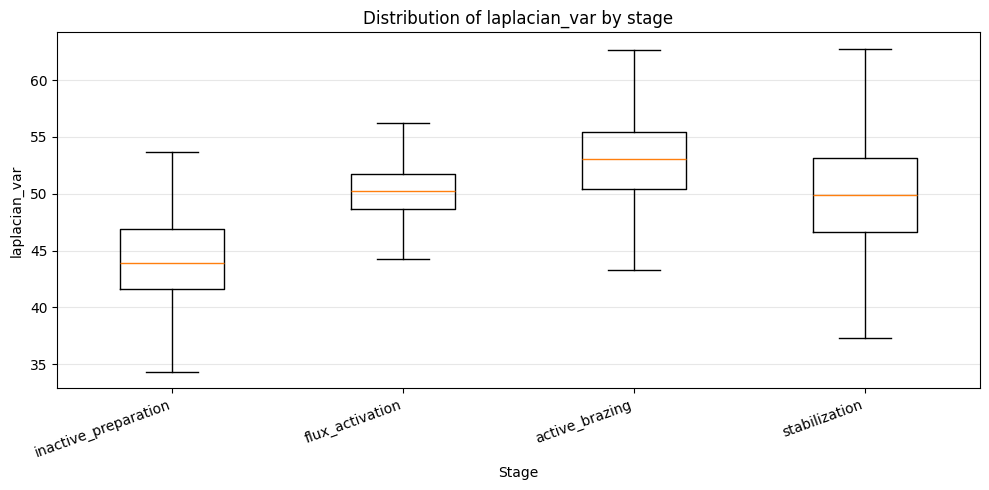

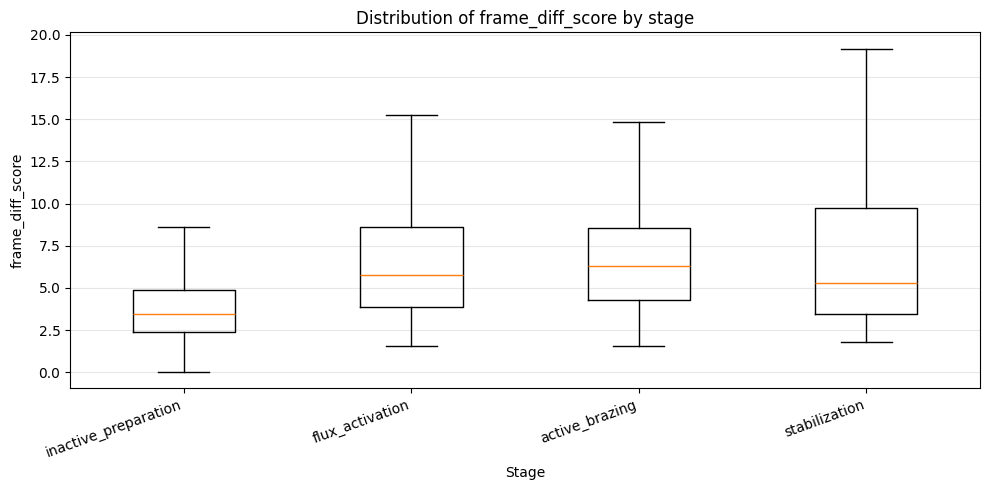

In [31]:
for feature in available_key_features:
    plt.figure(figsize=(10, 5))
    
    data = [
        features_df[features_df["stage_name"] == stage][feature].values
        for stage in STAGE_ORDER
    ]
    
    plt.boxplot(data, labels=STAGE_ORDER, showfliers=False)
    plt.title(f"Distribution of {feature} by stage")
    plt.xlabel("Stage")
    plt.ylabel(feature)
    plt.xticks(rotation=20, ha="right")
    plt.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    
    output_path = FIGURES_DIR / f"boxplot_{feature}.png"
    plt.savefig(output_path, dpi=160)
    plt.show()

### mean

In [32]:
stage_feature_means = (
    features_df
    .groupby("stage_name")[available_key_features]
    .mean()
    .reindex(STAGE_ORDER)
)

stage_feature_means

,brightness_mean,value_mean,saturation_mean,white_area_ratio,specular_highlight_ratio,edge_density,laplacian_var,frame_diff_score
stage_name,,,,,,,,
inactive_preparation,154.984609,174.564382,48.535518,0.427803,0.248651,0.042749,44.642767,3.905679
flux_activation,146.520666,165.843330,49.991360,0.369763,0.175566,0.046487,50.542994,6.689867
active_brazing,143.756073,162.458042,49.237368,0.348814,0.159397,0.050942,52.953970,6.644799
stabilization,139.819140,157.576221,47.939796,0.336407,0.155060,0.049325,50.008420,7.156495


In [33]:
stage_feature_std = (
    features_df
    .groupby("stage_name")[available_key_features]
    .std()
    .reindex(STAGE_ORDER)
)

stage_feature_std

,brightness_mean,value_mean,saturation_mean,white_area_ratio,specular_highlight_ratio,edge_density,laplacian_var,frame_diff_score
stage_name,,,,,,,,
inactive_preparation,5.352618,5.986389,7.057937,0.053823,0.055935,0.004066,4.946554,2.055265
flux_activation,7.860985,9.129101,5.497995,0.049486,0.069717,0.002864,3.462325,3.779956
active_brazing,7.362806,8.550615,6.395958,0.058544,0.049580,0.004721,4.906967,3.137669
stabilization,7.069782,8.581031,11.384722,0.082303,0.045845,0.007648,7.590269,4.752175


### normalized averages by stage

In [34]:
normalized_means = stage_feature_means.copy()

for col in normalized_means.columns:
    col_min = normalized_means[col].min()
    col_max = normalized_means[col].max()
    if col_max > col_min:
        normalized_means[col] = (normalized_means[col] - col_min) / (col_max - col_min)

normalized_means

,brightness_mean,value_mean,saturation_mean,white_area_ratio,specular_highlight_ratio,edge_density,laplacian_var,frame_diff_score
stage_name,,,,,,,,
inactive_preparation,1.000000,1.000000,0.290375,1.000000,1.000000,0.000000,0.000000,0.000000
flux_activation,0.441894,0.486639,1.000000,0.364960,0.219102,0.456327,0.709912,0.856458
active_brazing,0.259598,0.287366,0.632479,0.135754,0.046334,1.000000,1.000000,0.842595
stabilization,0.000000,0.000000,0.000000,0.000000,0.000000,0.802714,0.645593,1.000000


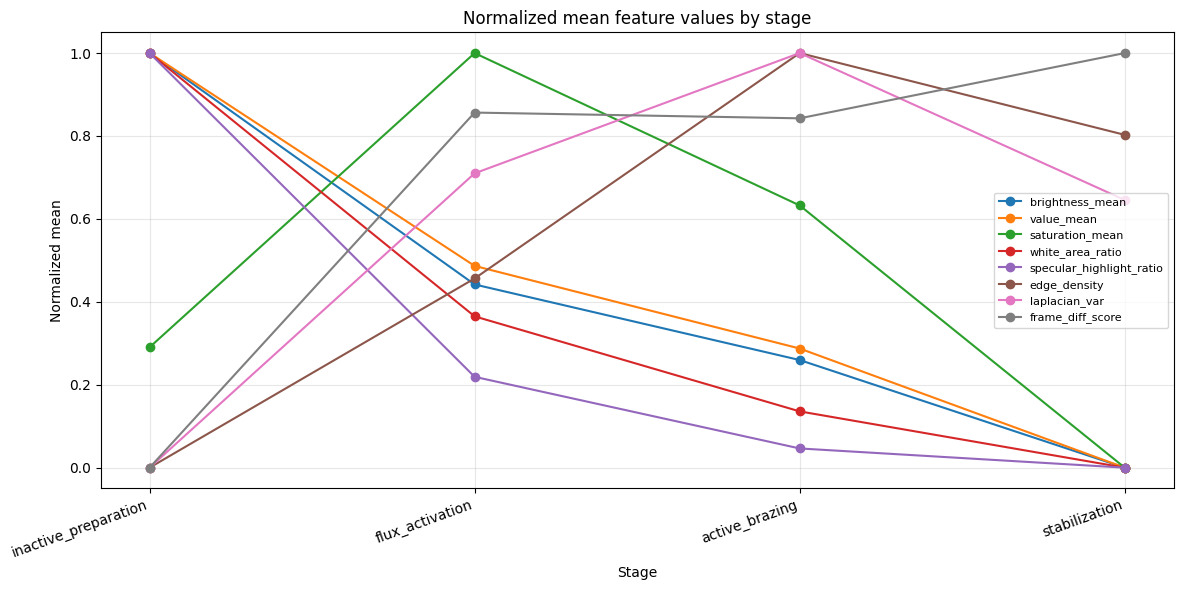

In [35]:
plt.figure(figsize=(12, 6))

for feature in normalized_means.columns:
    plt.plot(
        STAGE_ORDER,
        normalized_means[feature],
        marker="o",
        label=feature,
    )

plt.title("Normalized mean feature values by stage")
plt.xlabel("Stage")
plt.ylabel("Normalized mean")
plt.xticks(rotation=20, ha="right")
plt.grid(alpha=0.3)
plt.legend(loc="best", fontsize=8)
plt.tight_layout()

output_path = FIGURES_DIR / "normalized_feature_means_by_stage.png"
plt.savefig(output_path, dpi=160)
plt.show()

### corr

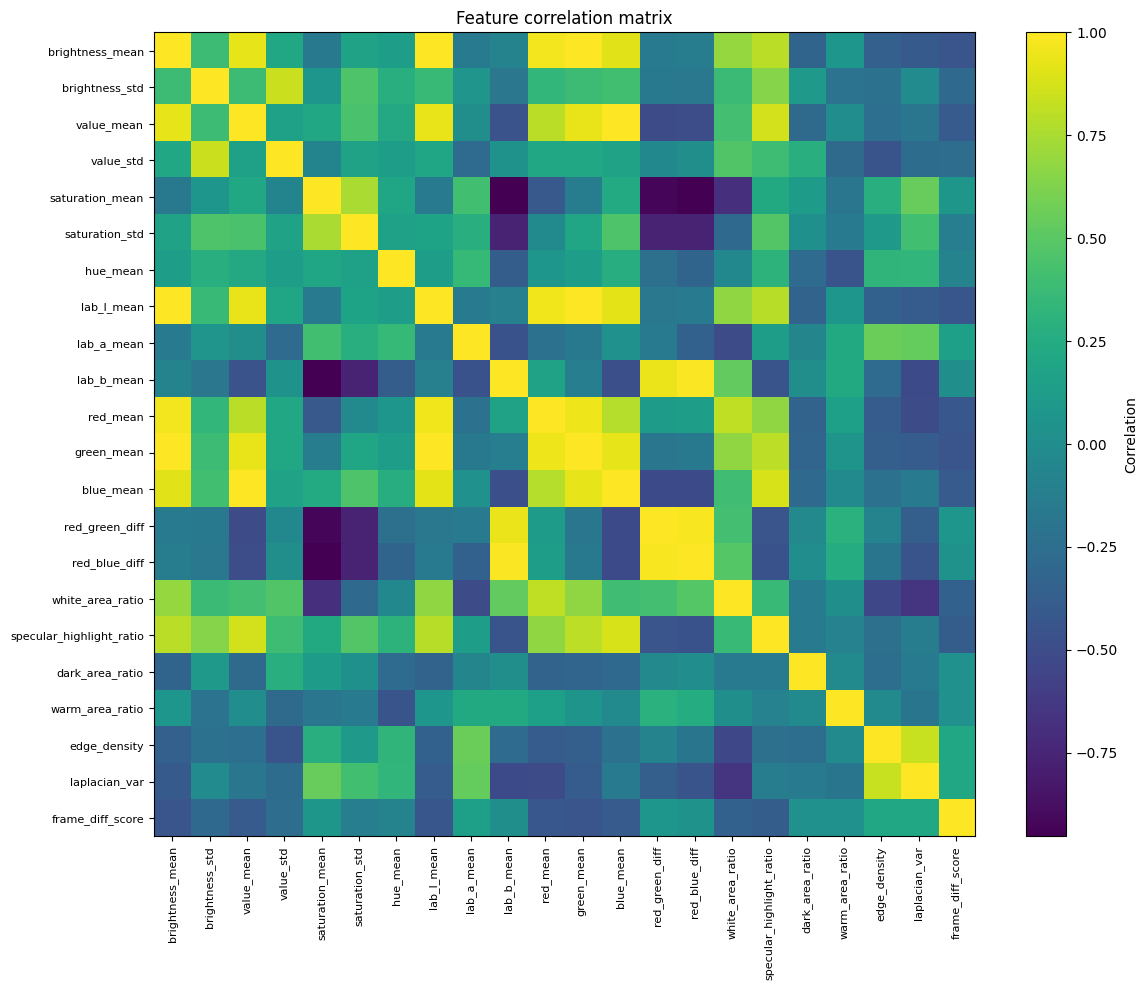

In [36]:
corr = features_df[feature_columns].corr()

plt.figure(figsize=(12, 10))
plt.imshow(corr, aspect="auto")
plt.colorbar(label="Correlation")
plt.xticks(range(len(feature_columns)), feature_columns, rotation=90, fontsize=8)
plt.yticks(range(len(feature_columns)), feature_columns, fontsize=8)
plt.title("Feature correlation matrix")
plt.tight_layout()

output_path = FIGURES_DIR / "feature_correlation_matrix.png"
plt.savefig(output_path, dpi=160)
plt.show()

## train

### split

In [37]:
train_split = pd.read_csv(TRAIN_PATH)
val_split = pd.read_csv(VAL_PATH)
test_split = pd.read_csv(TEST_PATH)

print(train_split.shape, val_split.shape, test_split.shape)

(1731, 8) (328, 8) (521, 8)


In [38]:
train_paths = set(train_split["frame_path"])
val_paths = set(val_split["frame_path"])
test_paths = set(test_split["frame_path"])

train_df = features_df[features_df["frame_path"].isin(train_paths)].copy()
val_df = features_df[features_df["frame_path"].isin(val_paths)].copy()
test_df = features_df[features_df["frame_path"].isin(test_paths)].copy()

print("train:", train_df.shape)
print("val:", val_df.shape)
print("test:", test_df.shape)

assert len(train_df) == len(train_split)
assert len(val_df) == len(val_split)
assert len(test_df) == len(test_split)

train: (1731, 27)
val: (328, 27)
test: (521, 27)


In [39]:
def split_stage_counts(split_df):
    return split_df.groupby("stage_name").size().reindex(STAGE_ORDER).fillna(0).astype(int)

split_counts = pd.DataFrame({
    "train": split_stage_counts(train_df),
    "val": split_stage_counts(val_df),
    "test": split_stage_counts(test_df),
})

split_counts

,train,val,test
stage_name,,,
inactive_preparation,1072,222,302
flux_activation,148,29,41
active_brazing,229,42,58
stabilization,282,35,120


### x/y

In [40]:
X_train = train_df[feature_columns].values
y_train = train_df["stage_id"].values

X_val = val_df[feature_columns].values
y_val = val_df["stage_id"].values

X_test = test_df[feature_columns].values
y_test = test_df["stage_id"].values

print(X_train.shape, y_train.shape)
print(X_val.shape, y_val.shape)
print(X_test.shape, y_test.shape)

(1731, 22) (1731,)
(328, 22) (328,)
(521, 22) (521,)


### models

In [41]:
def evaluate_model(model, X, y, split_name: str):
    y_pred = model.predict(X)
    
    acc = accuracy_score(y, y_pred)
    macro_f1 = f1_score(y, y_pred, average="macro")
    weighted_f1 = f1_score(y, y_pred, average="weighted")
    
    print(f"{split_name}")
    print("-" * 80)
    print(f"accuracy:    {acc:.4f}")
    print(f"macro_f1:    {macro_f1:.4f}")
    print(f"weighted_f1: {weighted_f1:.4f}")
    print()
    
    print(classification_report(
        y,
        y_pred,
        labels=[0, 1, 2, 3],
        target_names=STAGE_ORDER,
        digits=4,
        zero_division=0,
    ))
    
    cm = confusion_matrix(y, y_pred, labels=[0, 1, 2, 3])
    
    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=STAGE_ORDER,
    )
    
    fig, ax = plt.subplots(figsize=(8, 7))
    disp.plot(ax=ax, xticks_rotation=30, values_format="d")
    ax.set_title(f"Confusion Matrix — {split_name}")
    plt.tight_layout()
    plt.show()
    
    return {
        "accuracy": acc,
        "macro_f1": macro_f1,
        "weighted_f1": weighted_f1,
        "confusion_matrix": cm.tolist(),
    }

#### Logistic Regression

Validation — Logistic Regression
--------------------------------------------------------------------------------
accuracy:    0.9177
macro_f1:    0.8281
weighted_f1: 0.9194

                      precision    recall  f1-score   support

inactive_preparation     1.0000    0.9820    0.9909       222
     flux_activation     0.6042    1.0000    0.7532        29
      active_brazing     0.7879    0.6190    0.6933        42
       stabilization     0.9655    0.8000    0.8750        35

            accuracy                         0.9177       328
           macro avg     0.8394    0.8503    0.8281       328
        weighted avg     0.9342    0.9177    0.9194       328



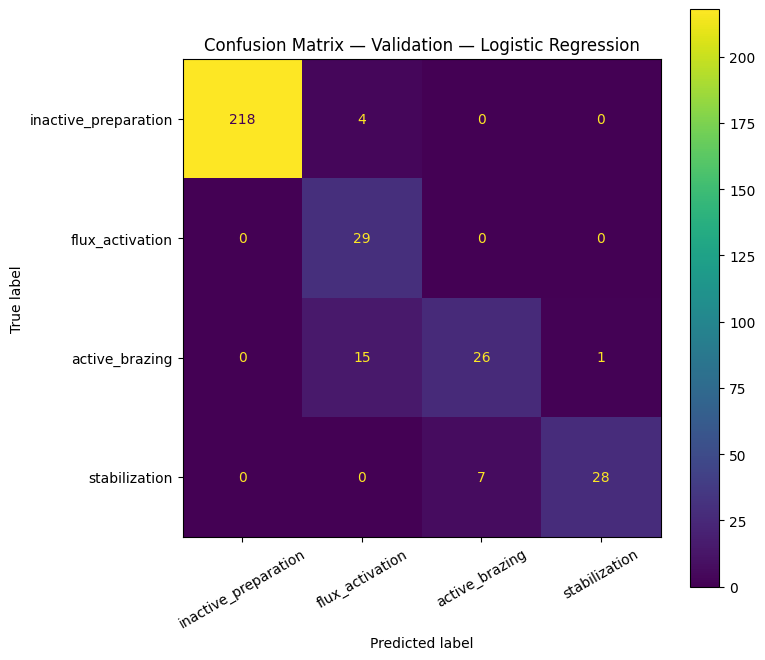

In [42]:
logreg_model = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(
        max_iter=5000,
        class_weight="balanced",
        random_state=42,
        multi_class="auto",
    )),
])

logreg_model.fit(X_train, y_train)

logreg_val_metrics = evaluate_model(logreg_model, X_val, y_val, "Validation — Logistic Regression")

#### Random Forest

Validation — Random Forest
--------------------------------------------------------------------------------
accuracy:    0.8963
macro_f1:    0.7903
weighted_f1: 0.8894

                      precision    recall  f1-score   support

inactive_preparation     0.9212    1.0000    0.9590       222
     flux_activation     0.6522    0.5172    0.5769        29
      active_brazing     0.8485    0.6667    0.7467        42
       stabilization     0.9355    0.8286    0.8788        35

            accuracy                         0.8963       328
           macro avg     0.8393    0.7531    0.7903       328
        weighted avg     0.8896    0.8963    0.8894       328



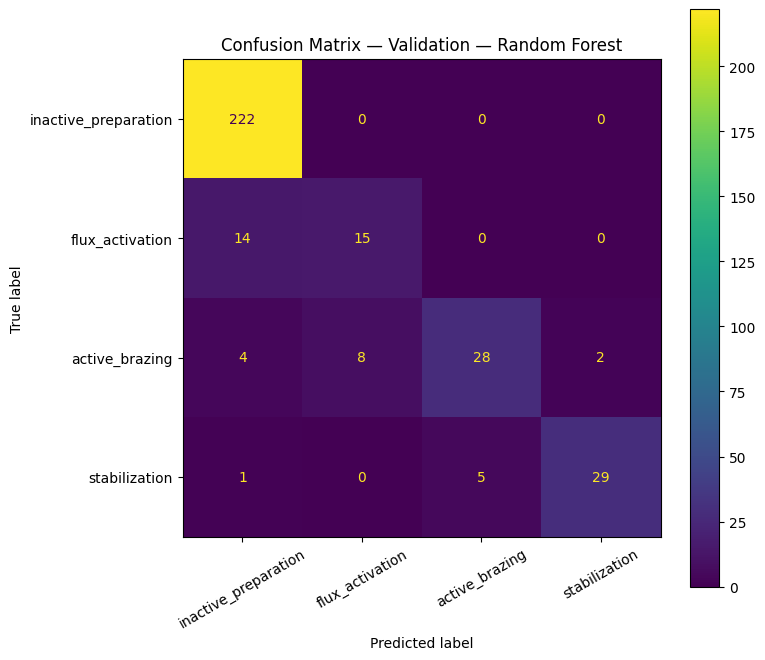

In [43]:
rf_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    min_samples_leaf=3,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1,
)

rf_model.fit(X_train, y_train)

rf_val_metrics = evaluate_model(rf_model, X_val, y_val, "Validation — Random Forest")

#### Gradient Boosting

Validation — Gradient Boosting
--------------------------------------------------------------------------------
accuracy:    0.8659
macro_f1:    0.7193
weighted_f1: 0.8574

                      precision    recall  f1-score   support

inactive_preparation     0.9212    1.0000    0.9590       222
     flux_activation     0.6087    0.4828    0.5385        29
      active_brazing     0.6500    0.6190    0.6341        42
       stabilization     0.9167    0.6286    0.7458        35

            accuracy                         0.8659       328
           macro avg     0.7741    0.6826    0.7193       328
        weighted avg     0.8583    0.8659    0.8574       328



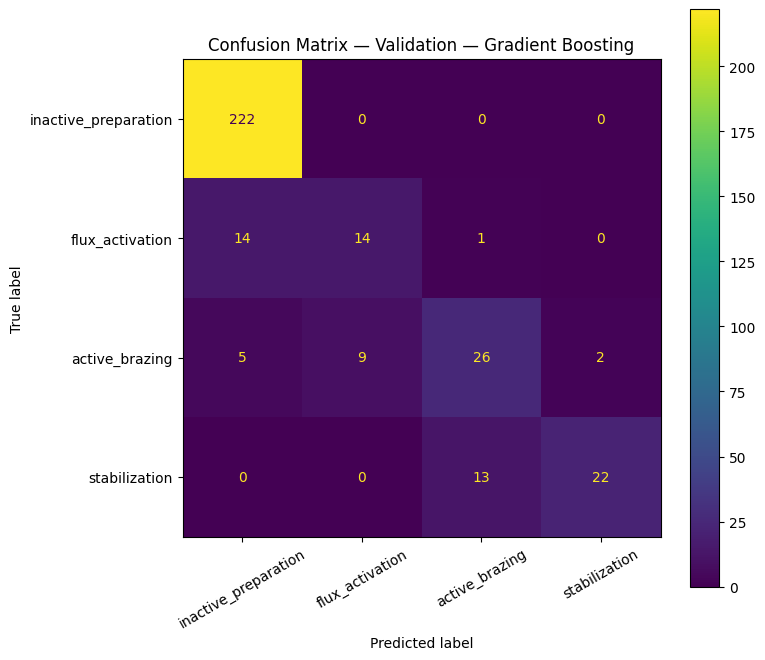

In [44]:
gb_model = GradientBoostingClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=3,
    random_state=42,
)

gb_model.fit(X_train, y_train)

gb_val_metrics = evaluate_model(gb_model, X_val, y_val, "Validation — Gradient Boosting")

#### versus

In [45]:
model_metrics = pd.DataFrame([
    {
        "model": "LogisticRegression",
        **{k: v for k, v in logreg_val_metrics.items() if k != "confusion_matrix"},
    },
    {
        "model": "RandomForest",
        **{k: v for k, v in rf_val_metrics.items() if k != "confusion_matrix"},
    },
    {
        "model": "GradientBoosting",
        **{k: v for k, v in gb_val_metrics.items() if k != "confusion_matrix"},
    },
])

model_metrics

,model,accuracy,macro_f1,weighted_f1
0,LogisticRegression,0.917683,0.828122,0.919424
1,RandomForest,0.896341,0.790335,0.889446
2,GradientBoosting,0.865854,0.719333,0.857442


In [46]:
model_metrics.to_csv(REPORTS_DIR / f"cv_baseline_validation_metric_{FPS}.csv", index=False)

#### test

In [47]:
best_model_name = model_metrics.sort_values("macro_f1", ascending=False).iloc[0]["model"]
best_model_name

'LogisticRegression'

In [48]:
models = {
    "LogisticRegression": logreg_model,
    "RandomForest": rf_model,
    "GradientBoosting": gb_model,
}

best_model = models[best_model_name]
best_model

Pipeline(steps=[('scaler', StandardScaler()),
                ('clf',
                 LogisticRegression(class_weight='balanced', max_iter=5000,
                                    multi_class='auto', random_state=42))])

Test — LogisticRegression
--------------------------------------------------------------------------------
accuracy:    0.6219
macro_f1:    0.5740
weighted_f1: 0.6904

                      precision    recall  f1-score   support

inactive_preparation     0.9707    0.6589    0.7850       302
     flux_activation     0.1692    0.8293    0.2810        41
      active_brazing     0.6111    0.5690    0.5893        58
       stabilization     0.9508    0.4833    0.6409       120

            accuracy                         0.6219       521
           macro avg     0.6755    0.6351    0.5740       521
        weighted avg     0.8630    0.6219    0.6904       521



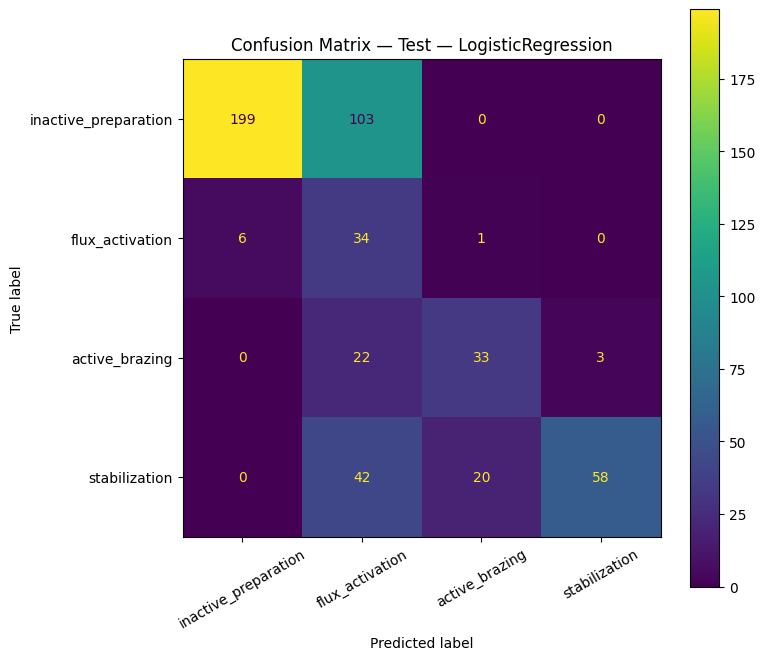

{'accuracy': 0.6218809980806143,
 'macro_f1': 0.574042822414099,
 'weighted_f1': 0.6903613977685413,
 'confusion_matrix': [[199, 103, 0, 0],
  [6, 34, 1, 0],
  [0, 22, 33, 3],
  [0, 42, 20, 58]]}

In [49]:
test_metrics = evaluate_model(best_model, X_test, y_test, f"Test — {best_model_name}")
test_metrics

In [50]:
with open(REPORTS_DIR / f"cv_baseline_test_metrics_{FPS}.json", "w", encoding="utf-8") as f:
    json.dump(
        {
            "best_model": best_model_name,
            "test_metrics": {
                "accuracy": test_metrics["accuracy"],
                "macro_f1": test_metrics["macro_f1"],
                "weighted_f1": test_metrics["weighted_f1"],
                "confusion_matrix": test_metrics["confusion_matrix"],
            },
            "stage_order": STAGE_ORDER,
            "feature_columns": feature_columns,
        },
        f,
        ensure_ascii=False,
        indent=2,
    )

#### features importance

In [51]:
if best_model_name == "RandomForest":
    importances = best_model.feature_importances_
    
    feature_importance_df = pd.DataFrame({
        "feature": feature_columns,
        "importance": importances,
    }).sort_values("importance", ascending=False)
else:
    result = permutation_importance(
        best_model,
        X_val,
        y_val,
        n_repeats=10,
        random_state=42,
        n_jobs=-1,
        scoring="f1_macro",
    )
    
    feature_importance_df = pd.DataFrame({
        "feature": feature_columns,
        "importance": result.importances_mean,
        "importance_std": result.importances_std,
    }).sort_values("importance", ascending=False)

feature_importance_df

,feature,importance,importance_std
3,value_std,0.181666,0.017831
20,laplacian_var,0.178563,0.018418
15,white_area_ratio,0.146570,0.018785
4,saturation_mean,0.144038,0.017082
5,saturation_std,0.135215,0.019502
1,brightness_std,0.126083,0.018411
9,lab_b_mean,0.104117,0.016052
13,red_green_diff,0.089524,0.013513
16,specular_highlight_ratio,0.087457,0.015521
8,lab_a_mean,0.062875,0.007865


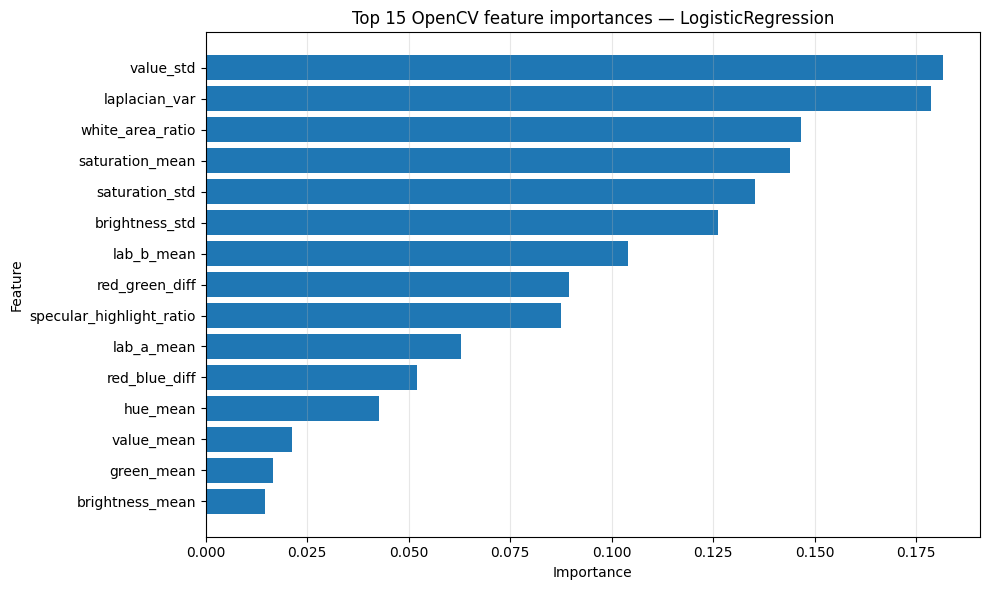

In [52]:
feature_importance_df.to_csv(
    REPORTS_DIR / f"cv_feature_importance_{FPS}.csv",
    index=False,
)

top_n = min(15, len(feature_importance_df))
top_features = feature_importance_df.head(top_n)

plt.figure(figsize=(10, 6))
plt.barh(top_features["feature"][::-1], top_features["importance"][::-1])
plt.title(f"Top {top_n} OpenCV feature importances — {best_model_name}")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.grid(axis="x", alpha=0.3)
plt.tight_layout()

output_path = FIGURES_DIR / f"cv_feature_importance.png"
plt.savefig(output_path, dpi=160)
plt.show()

#### model error

In [53]:
test_pred = best_model.predict(X_test)

test_errors_df = test_df.copy()
test_errors_df["pred_stage_id"] = test_pred
test_errors_df["pred_stage_name"] = test_errors_df["pred_stage_id"].map(ID_TO_STAGE)
test_errors_df["is_correct"] = test_errors_df["stage_id"] == test_errors_df["pred_stage_id"]

errors_df = test_errors_df[~test_errors_df["is_correct"]].copy()

print("Test errors:", len(errors_df), "of", len(test_errors_df))
errors_df[[
    "video_id",
    "timestamp_s",
    "stage_name",
    "pred_stage_name",
    "frame_path",
]].head(30)

Test errors: 197 of 521


,video_id,timestamp_s,stage_name,pred_stage_name,frame_path
0,MVI_6265,0.000000,inactive_preparation,flux_activation,data/processed/frames_3/MVI_6265/MVI_6265_0000...
1,MVI_6265,0.333333,inactive_preparation,flux_activation,data/processed/frames_3/MVI_6265/MVI_6265_0000...
2,MVI_6265,0.666667,inactive_preparation,flux_activation,data/processed/frames_3/MVI_6265/MVI_6265_0000...
3,MVI_6265,1.000000,inactive_preparation,flux_activation,data/processed/frames_3/MVI_6265/MVI_6265_0000...
4,MVI_6265,1.333333,inactive_preparation,flux_activation,data/processed/frames_3/MVI_6265/MVI_6265_0000...
5,MVI_6265,1.666667,inactive_preparation,flux_activation,data/processed/frames_3/MVI_6265/MVI_6265_0000...
6,MVI_6265,2.000000,inactive_preparation,flux_activation,data/processed/frames_3/MVI_6265/MVI_6265_0000...
7,MVI_6265,2.333333,inactive_preparation,flux_activation,data/processed/frames_3/MVI_6265/MVI_6265_0000...
8,MVI_6265,2.666667,inactive_preparation,flux_activation,data/processed/frames_3/MVI_6265/MVI_6265_0000...
9,MVI_6265,3.000000,inactive_preparation,flux_activation,data/processed/frames_3/MVI_6265/MVI_6265_0000...


In [54]:
error_pairs = (
    errors_df
    .groupby(["stage_name", "pred_stage_name"])
    .size()
    .reset_index(name="count")
    .sort_values("count", ascending=False)
)

error_pairs

,stage_name,pred_stage_name,count
4,inactive_preparation,flux_activation,103
6,stabilization,flux_activation,42
0,active_brazing,flux_activation,22
5,stabilization,active_brazing,20
3,flux_activation,inactive_preparation,6
1,active_brazing,stabilization,3
2,flux_activation,active_brazing,1


#### plot_predictions_for_video

In [55]:
def plot_predictions_for_video(video_id: str):
    video_df = test_errors_df[test_errors_df["video_id"] == video_id].sort_values("timestamp_s")
    
    if len(video_df) == 0:
        print(f"No test rows for {video_id}")
        return
    
    plt.figure(figsize=(14, 4))
    
    plt.scatter(
        video_df["timestamp_s"],
        video_df["stage_id"],
        s=30,
        label="true",
        marker="o",
    )
    
    plt.scatter(
        video_df["timestamp_s"],
        video_df["pred_stage_id"],
        s=18,
        label="pred",
        marker="x",
    )
    
    plt.yticks([0, 1, 2, 3], STAGE_ORDER)
    plt.xlabel("Time, s")
    plt.ylabel("Stage")
    plt.title(f"True vs predicted stages — {video_id}")
    plt.grid(alpha=0.3)
    plt.legend()
    plt.tight_layout()
    
    output_path = FIGURES_DIR / f"{video_id}_cv_predictions_timeline.png"
    plt.savefig(output_path, dpi=160)
    plt.show()

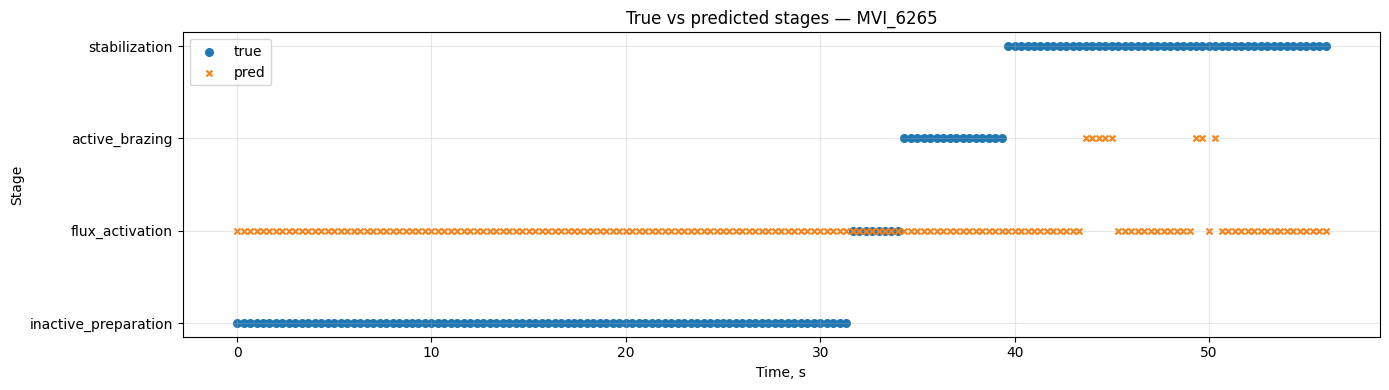

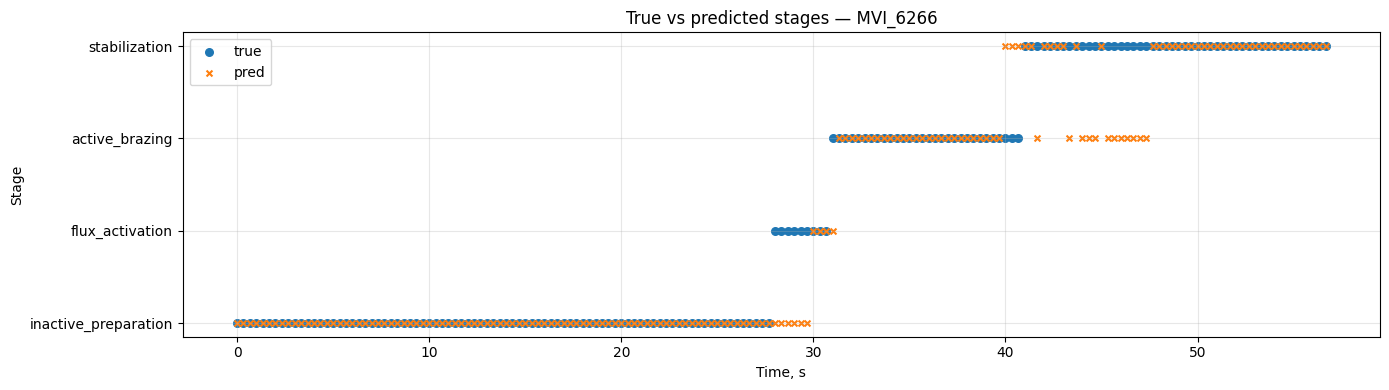

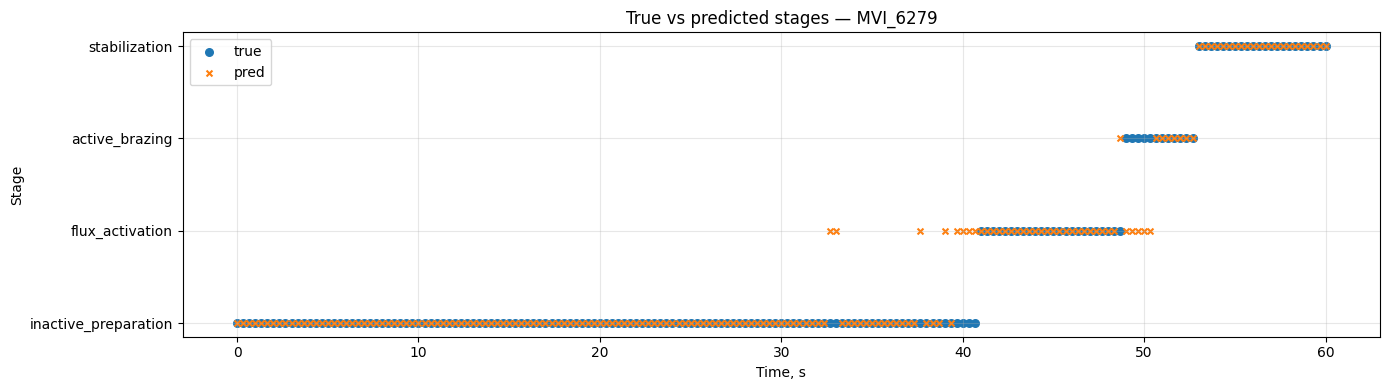

In [56]:
for video_id in sorted(test_df["video_id"].unique()):
    plot_predictions_for_video(video_id)

## temporal smoothing

In [57]:
def smooth_stage_predictions(
    video_df: pd.DataFrame,
    pred_col: str = "pred_stage_id",
    output_col: str = "pred_stage_id_smooth",
    window_size: int = 5,
) -> pd.DataFrame:
    """
    Majority-vote smoothing over stage predictions for one video.
    window_size should be odd: 3, 5, 7, 9.
    """
    video_df = video_df.sort_values("timestamp_s").copy()
    preds = video_df[pred_col].to_numpy()

    half = window_size // 2
    smoothed = []

    for i in range(len(preds)):
        left = max(0, i - half)
        right = min(len(preds), i + half + 1)

        window = preds[left:right]
        most_common_stage = Counter(window).most_common(1)[0][0]
        smoothed.append(most_common_stage)

    video_df[output_col] = smoothed
    video_df["pred_stage_name_smooth"] = video_df[output_col].map(ID_TO_STAGE)

    return video_df

In [58]:
test_pred = best_model.predict(X_test)

test_pred_df = test_df.copy()
test_pred_df["pred_stage_id"] = test_pred
test_pred_df["pred_stage_name"] = test_pred_df["pred_stage_id"].map(ID_TO_STAGE)

smoothed_parts = []

for video_id, video_df in test_pred_df.groupby("video_id"):
    smoothed_video_df = smooth_stage_predictions(
        video_df,
        pred_col="pred_stage_id",
        output_col="pred_stage_id_smooth",
        window_size=5,
    )
    smoothed_parts.append(smoothed_video_df)

test_smoothed_df = pd.concat(smoothed_parts).sort_values(
    ["video_id", "timestamp_s"]
).reset_index(drop=True)

test_smoothed_df.head()

,video_id,frame_path,timestamp_s,stage_id,stage_name,brightness_mean,brightness_std,value_mean,value_std,saturation_mean,...,specular_highlight_ratio,dark_area_ratio,warm_area_ratio,edge_density,laplacian_var,frame_diff_score,pred_stage_id,pred_stage_name,pred_stage_id_smooth,pred_stage_name_smooth
0,MVI_6265,data/processed/frames_3/MVI_6265/MVI_6265_0000...,0.000000,0,inactive_preparation,145.025702,56.764680,179.579174,59.605029,81.634146,...,0.295285,0.001684,0.000513,0.047298,63.083993,0.000000,1,flux_activation,1,flux_activation
1,MVI_6265,data/processed/frames_3/MVI_6265/MVI_6265_0000...,0.333333,0,inactive_preparation,144.239944,56.803818,178.913737,60.100888,82.045766,...,0.293689,0.002943,0.000601,0.044996,52.564422,9.295525,1,flux_activation,1,flux_activation
2,MVI_6265,data/processed/frames_3/MVI_6265/MVI_6265_0000...,0.666667,0,inactive_preparation,142.540722,56.373133,177.178613,60.250726,82.260545,...,0.277763,0.004956,0.000449,0.047233,64.375782,18.387129,1,flux_activation,1,flux_activation
3,MVI_6265,data/processed/frames_3/MVI_6265/MVI_6265_0000...,1.000000,0,inactive_preparation,142.187306,56.462278,176.990377,60.168118,82.545638,...,0.275397,0.005076,0.000481,0.048404,61.407665,7.876993,1,flux_activation,1,flux_activation
4,MVI_6265,data/processed/frames_3/MVI_6265/MVI_6265_0000...,1.333333,0,inactive_preparation,142.097017,56.628473,177.135381,60.244167,82.938773,...,0.278123,0.004675,0.000609,0.047193,62.888918,2.078292,1,flux_activation,1,flux_activation


Test — LogisticRegression + temporal smoothing
--------------------------------------------------------------------------------
accuracy: 0.6295585412667947
macro_f1: 0.58087431804523
weighted_f1: 0.6964417727255893
                      precision    recall  f1-score   support

inactive_preparation     0.9712    0.6689    0.7922       302
     flux_activation     0.1750    0.8537    0.2905        41
      active_brazing     0.6346    0.5690    0.6000        58
       stabilization     0.9508    0.4833    0.6409       120

            accuracy                         0.6296       521
           macro avg     0.6829    0.6437    0.5809       521
        weighted avg     0.8664    0.6296    0.6964       521



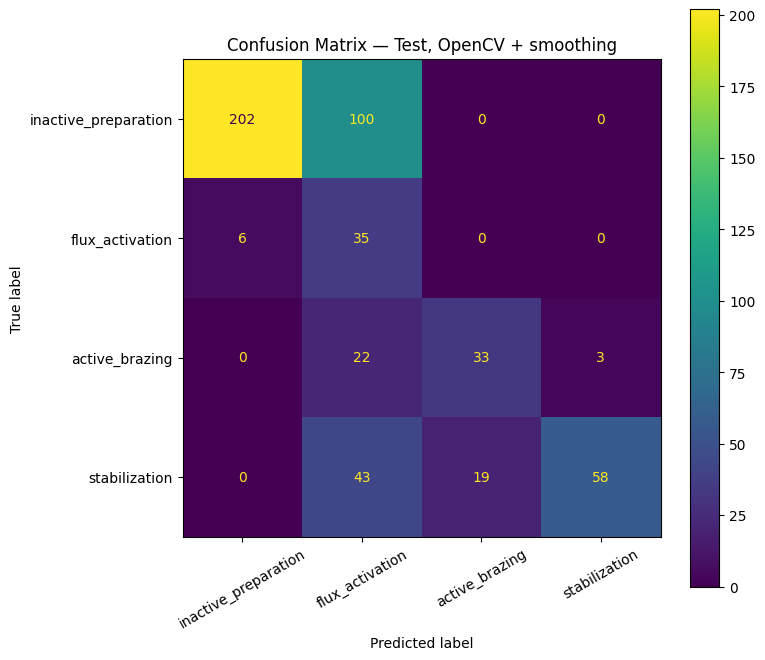

In [59]:
y_test_smooth = test_smoothed_df["stage_id"].to_numpy()
y_pred_smooth = test_smoothed_df["pred_stage_id_smooth"].to_numpy()

print("Test — LogisticRegression + temporal smoothing")
print("-" * 80)
print("accuracy:", accuracy_score(y_test_smooth, y_pred_smooth))
print("macro_f1:", f1_score(y_test_smooth, y_pred_smooth, average="macro"))
print("weighted_f1:", f1_score(y_test_smooth, y_pred_smooth, average="weighted"))

print(classification_report(
    y_test_smooth,
    y_pred_smooth,
    labels=[0, 1, 2, 3],
    target_names=STAGE_ORDER,
    digits=4,
    zero_division=0,
))

cm = confusion_matrix(y_test_smooth, y_pred_smooth, labels=[0, 1, 2, 3])

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=STAGE_ORDER,
)

fig, ax = plt.subplots(figsize=(8, 7))
disp.plot(ax=ax, xticks_rotation=30, values_format="d")
ax.set_title("Confusion Matrix — Test, OpenCV + smoothing")
plt.tight_layout()
plt.show()

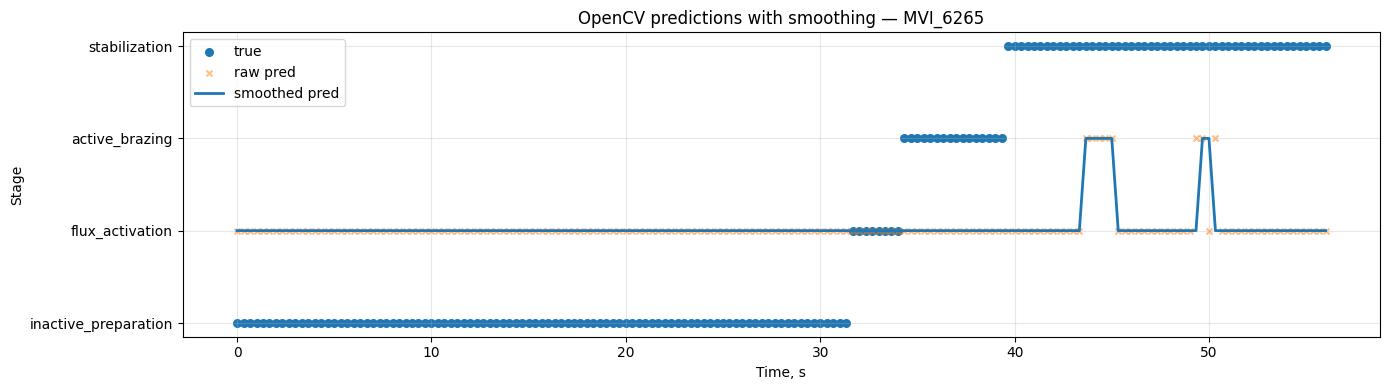

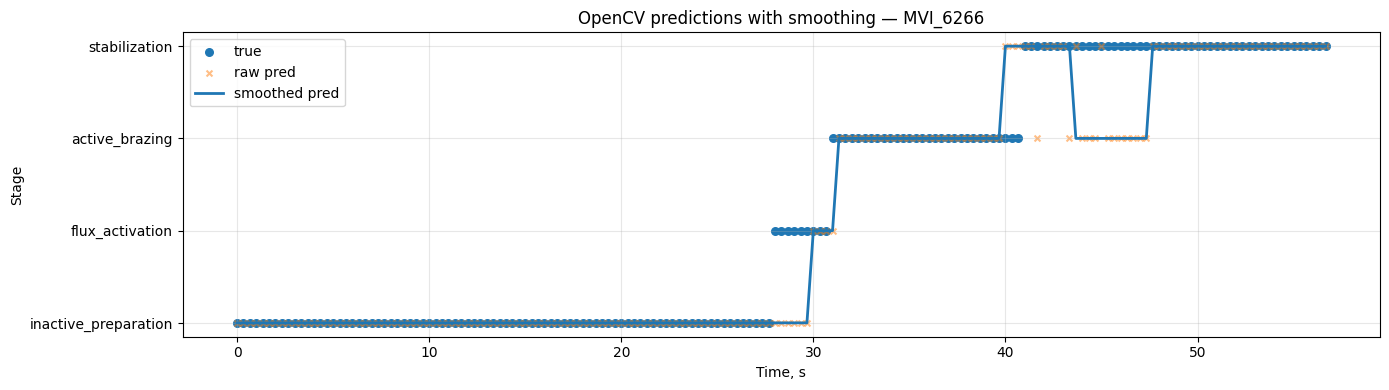

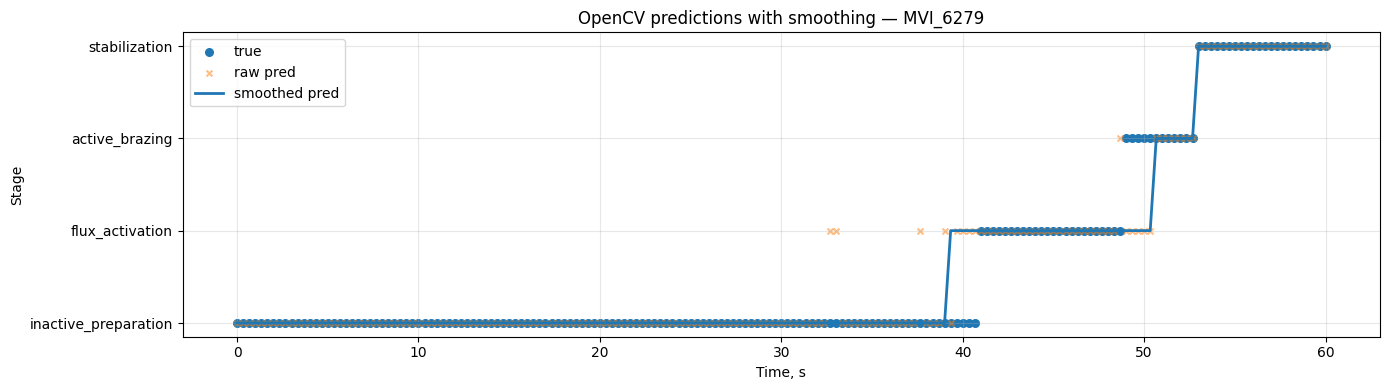

In [60]:
def plot_smoothed_predictions_for_video(video_id: str):
    video_df = test_smoothed_df[
        test_smoothed_df["video_id"] == video_id
    ].sort_values("timestamp_s")

    plt.figure(figsize=(14, 4))

    plt.scatter(
        video_df["timestamp_s"],
        video_df["stage_id"],
        s=30,
        label="true",
        marker="o",
    )

    plt.scatter(
        video_df["timestamp_s"],
        video_df["pred_stage_id"],
        s=18,
        label="raw pred",
        marker="x",
        alpha=0.5,
    )

    plt.plot(
        video_df["timestamp_s"],
        video_df["pred_stage_id_smooth"],
        label="smoothed pred",
        linewidth=2,
    )

    plt.yticks([0, 1, 2, 3], STAGE_ORDER)
    plt.xlabel("Time, s")
    plt.ylabel("Stage")
    plt.title(f"OpenCV predictions with smoothing — {video_id}")
    plt.grid(alpha=0.3)
    plt.legend()
    plt.tight_layout()

    output_path = FIGURES_DIR / f"{video_id}_cv_predictions_smoothed_timeline.png"
    plt.savefig(output_path, dpi=160)
    plt.show()


for video_id in sorted(test_df["video_id"].unique()):
    plot_smoothed_predictions_for_video(video_id)

# results

## Итоговый вывод по OpenCV baseline

В рамках морфологической ветки был реализован baseline-подход на основе классических признаков компьютерного зрения, рассчитанных в области интереса зоны пайки. В качестве области интереса использовался ROI, включающий волновод, область флюса, нижний шов и зоны возможного протекания припоя. Такой подход позволил исключить значительную часть фона и сосредоточить анализ на визуально значимой части кадра.

Для каждого кадра были рассчитаны признаки яркости, насыщенности, цветовых каналов, доли светлых областей, доли бликов, плотности границ, текстурности и межкадрового изменения. На основе этих признаков были обучены классические модели машинного обучения. Лучший результат на тестовой выборке показала модель Logistic Regression.

Итоговое качество OpenCV baseline на тестовой выборке:

```text
accuracy:    0.6219
macro_f1:    0.5740
weighted_f1: 0.6904
````

После применения простого временного сглаживания качество немного улучшилось:

```text
accuracy:    0.6296
macro_f1:    0.5809
weighted_f1: 0.6964
```

По результатам классификации видно, что стадии `inactive_preparation` и `stabilization` распознаются с высокой точностью предсказания. Для них модель показывает высокие значения precision:

```text
inactive_preparation precision = 0.9712
stabilization precision        = 0.9508
```

Это означает, что если модель относит кадр к подготовительной стадии или стадии стабилизации, такое решение обычно является корректным.

Наиболее сложной стадией оказалась `flux_activation`. Для неё модель показала высокий recall:

```text
flux_activation recall = 0.8537
```

Однако precision для этой стадии остаётся низким:

```text
flux_activation precision = 0.1750
```

Это означает, что модель достаточно хорошо находит большинство настоящих кадров активации флюса, но при этом часто ошибочно относит к этой стадии кадры из других этапов процесса.

Основные ошибки модели:

```text
inactive_preparation → flux_activation: 103
stabilization → flux_activation: 42
active_brazing → flux_activation: 22
stabilization → active_brazing: 20
```

Таким образом, OpenCV-признаки хорошо отражают общее изменение визуального состояния зоны пайки, но недостаточно устойчиво отделяют активацию флюса от соседних стадий. Это связано с тем, что визуальные признаки `flux_activation` частично пересекаются с признаками подготовительной стадии, активной пайки и стабилизации: в кадре меняются яркость, блики, текстура и локальные неоднородности, но эти изменения не всегда однозначно соответствуют только активации флюса.

Временное сглаживание дало небольшой положительный эффект, однако не решило основную проблему ложных срабатываний по классу `flux_activation`. Это показывает, что простого majority-vote сглаживания недостаточно. Для более устойчивого операторского решения требуется либо более сложная логика переходов между стадиями, либо применение нейросетевого подхода, способного учитывать более сложные пространственные признаки изображения.

Итоговый вывод: морфологический подход на основе OpenCV-признаков пригоден как объяснимый baseline и диагностический инструмент для анализа визуальных изменений в зоне пайки. Он позволяет частично различать стадии процесса и даёт интерпретируемые признаки, связанные с яркостью, бликами, текстурой и межкадровыми изменениями. Однако в текущем виде такой подход недостаточен как финальное решение задачи, прежде всего из-за низкой точности определения стадии `flux_activation`. 


